##Analisis Exploratorio de Datos

El dataset Spanish Fake News Corpus Versión 2.0 contiene pares de publicaciones falsas y verdaderas sobre diferentes eventos, recolectadas entre noviembre de 2020 y marzo de 2021. Las fuentes principales fueron dos tipos: sitios web de periódicos y medios de comunicación, y sitios web de verificación de hechos que siguen recomendaciones de la International Fact-Checking Network (IFCN).
##Características del Corpus Versión 2.0
- Tamaño: 572 instancias (pares falso-verdadero balanceados)
- Clases: Binaria (Verdadero / Falso)
- Distribución de variantes: Incluye múltiples variantes del español de 13 países: Argentina, Bolivia, Chile, Colombia, Costa Rica, Ecuador, España, Estados Unidos, Francia, Perú, Uruguay, Inglaterra y Venezuela
##Temas Cubiertos
Ciencia, Deporte, Política, Sociedad, COVID-19, Medio Ambiente, Internacional.
##Composición del Contenido
El corpus incluye principalmente artículos de noticias, pero también 90 publicaciones de redes sociales (15.73% del total) recuperadas principalmente de Facebook y WhatsApp.
##Estructura de Datos
- Id: Identificador único por instancia
- Category: Clasificación (True/Fake)
- Topic: Categoría temática
- Source: Nombre de la fuente
- Headline: Encabezado de la noticia (algunos vacíos por omisión de fuente)
- Text: Texto completo
- Link: URL de origen
##Metodología de Etiquetado
Una noticia falsa se añade si algún sitio de verificación de hechos la identifica. Su contraparte verdadera se añade si existe evidencia de publicación en sitios confiables (periódicos establecidos o medios reconocidos).


### Importar librerías

In [ ]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import spacy
from collections import Counter

In [ ]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 64.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
dataset = load_dataset("mariagrandury/fake_news_corpus_spanish")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/924 [00:00<?, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating test split:   0%|          | 0/572 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['ID', 'CATEGORY', 'TOPICS', 'SOURCE', 'HEADLINE', 'TEXT', 'LINK'],
        num_rows: 572
    })
})


##Nota
Como se puede observar de incluyo todo la particion test, al finalizar el eda se dividira en 2 particiones train y test.

In [ ]:
df = dataset["test"].to_pandas()

## 1. Comprensión inicial del dataset



In [ ]:
print("Filas y columnas:", df.shape)

Filas y columnas: (572, 7)


In [ ]:
print("Columnas:")
df.columns

Columnas:


Index(['ID', 'CATEGORY', 'TOPICS', 'SOURCE', 'HEADLINE', 'TEXT', 'LINK'], dtype='object')

In [ ]:
display(df.head())

,ID,CATEGORY,TOPICS,SOURCE,HEADLINE,TEXT,LINK
0,1,True,Covid-19,El Economista,Covid-19: mentiras que matan,El control de la Covid-19 no es sólo un tema d...,https://www.eleconomista.com.mx/opinion/Covid-...
1,2,False,Política,El matinal,El Gobierno podrá acceder a las IPs de los móv...,El Gobierno de Pedro Sánchez y Pablo Iglesias ...,https://www.elmatinal.com/espana-ultima-hora/e...
2,3,True,Política,El País,La comunidad musulmana catalana denuncia a Vox...,Las tres federaciones que agrupan al 90% de la...,https://elpais.com/espana/elecciones-catalanas...
3,4,False,Política,AFPFactual,None,Se han dado a conocer los datos electorales pr...,https://perma.cc/GYE6-SPMB
4,5,True,Sociedad,La Republica,El censo poblacional 2018 tendrá un costo de $...,La primera fase del censo será virtual y solo ...,https://www.larepublica.co/economia/el-censo-p...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        572 non-null    int64 
 1   CATEGORY  572 non-null    bool  
 2   TOPICS    572 non-null    object
 3   SOURCE    565 non-null    object
 4   HEADLINE  500 non-null    object
 5   TEXT      572 non-null    object
 6   LINK      569 non-null    object
dtypes: bool(1), int64(1), object(5)
memory usage: 27.5+ KB


In [ ]:
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
ID           int64
CATEGORY      bool
TOPICS      object
SOURCE      object
HEADLINE    object
TEXT        object
LINK        object
dtype: object


## Conclusion etapa 1
En la primera etapa del análisis exploratorio se realizó una inspección inicial del dataset fake_news_corpus_spanish, disponible en la plataforma Hugging Face bajo el repositorio mariagrandury/fake_news_corpus_spanish. Este conjunto de datos está compuesto por noticias en idioma español y está orientado a la detección automática de noticias falsas mediante técnicas de Procesamiento de Lenguaje Natural.

El dataset presenta un total de 572 registros y 7 variables, lo que lo convierte en un corpus de tamaño moderado adecuado para tareas de clasificación supervisada. Las variables identificadas en el conjunto de datos son: ID, CATEGORY, TOPICS, SOURCE, HEADLINE, TEXT y LINK.

La variable TEXT contiene el contenido completo de la noticia, constituyendo la principal fuente de información textual para el análisis. Asimismo, la variable HEADLINE representa el titular de la noticia, el cual también puede aportar información relevante en la identificación de patrones lingüísticos. Por otro lado, la variable CATEGORY corresponde a la variable objetivo, ya que indica si la noticia es falsa o verdadera, permitiendo abordar el problema como una tarea de clasificación binaria.

Adicionalmente, la variable TOPICS permite identificar el tema de la noticia (por ejemplo, política, salud, ciencia, entre otros), lo cual resulta útil para analizar la distribución de la desinformación según el contexto temático. Las variables SOURCE y LINK contienen información sobre la fuente de la noticia y su enlace original, respectivamente; sin embargo, estas no serán utilizadas directamente en el proceso de modelado.

En conjunto, el dataset presenta características propias de datos no estructurados, debido a la presencia de texto libre, lo que justifica el uso de técnicas de Procesamiento de Lenguaje Natural para su análisis y posterior modelización.

## 2. Identificación de la variable objetivo

In [ ]:
print("Valores únicos en CATEGORY:")
df["CATEGORY"].unique()

Valores únicos en CATEGORY:


array([ True, False])

In [ ]:
print("Cantidad de noticias por categoría:")
print(df["CATEGORY"].value_counts())

Cantidad de noticias por categoría:
CATEGORY
True     286
False    286
Name: count, dtype: int64


In [ ]:
print("Porcentaje por categoría:")
print((df["CATEGORY"].value_counts(normalize=True) * 100).round(2))

Porcentaje por categoría:
CATEGORY
True     50.0
False    50.0
Name: proportion, dtype: float64


In [ ]:
print("Ejemplos de noticias por categoría:")
display(df[["CATEGORY", "HEADLINE", "TEXT"]].head(10))

Ejemplos de noticias por categoría:


,CATEGORY,HEADLINE,TEXT
0,True,Covid-19: mentiras que matan,El control de la Covid-19 no es sólo un tema d...
1,False,El Gobierno podrá acceder a las IPs de los móv...,El Gobierno de Pedro Sánchez y Pablo Iglesias ...
2,True,La comunidad musulmana catalana denuncia a Vox...,Las tres federaciones que agrupan al 90% de la...
3,False,None,Se han dado a conocer los datos electorales pr...
4,True,El censo poblacional 2018 tendrá un costo de $...,La primera fase del censo será virtual y solo ...
5,False,None,Boooomm\nMUJERES VACUNADAS DE COVID ESTÁN MOST...
6,True,Fauci dice que fue sacado de contexto en un nu...,El Dr. Anthony Fauci no consintió en aparecer ...
7,False,Franja naranja de estado de guerra en chile,Los bbrazalete sanitarios estan normados bajo ...
8,False,Francia decreta el estado de emergencia y el t...,El Gobierno de Francia declarará el estado de ...
9,True,"Con 1.356 vacunas, Norte de Santander inició i...","Cúcuta (Norte de Santander), 19 de febrero de ..."


## Conclusion etapa 2

La variable objetivo del proyecto es **`CATEGORY`**, debido a que indica la clase de cada noticia y permite definir el problema como una tarea de **clasificación binaria**. En este dataset, la variable presenta dos valores posibles: **`True`** y **`False`**.

A partir de la revisión de la variable objetivo, se identificó que el conjunto de datos contiene **286 noticias clasificadas como `True`** y **286 noticias clasificadas como `False`**, lo que representa una distribución perfectamente balanceada del **50% para cada clase**.

| Categoría | Cantidad | Porcentaje |
| --------- | -------: | ---------: |
| True      |      286 |      50.0% |
| False     |      286 |      50.0% |

Esta distribución es favorable para el proceso de modelización, ya que evita un desbalance inicial entre clases. En problemas de clasificación, un dataset desbalanceado puede provocar que el modelo aprenda a favorecer la clase mayoritaria; sin embargo, en este caso ambas clases tienen la misma cantidad de registros.

Además, se revisaron ejemplos iniciales de noticias junto con sus titulares y textos. Esta inspección permitió confirmar que la columna **`TEXT`** contiene el contenido principal de la noticia, mientras que **`HEADLINE`** representa el titular. Ambas variables pueden ser útiles como entrada para el modelo, aunque el objetivo final será predecir la clase contenida en **`CATEGORY`**.





## 3. Distribución de clase CATEGORY


In [ ]:
conteo_clases = df["CATEGORY"].value_counts().reset_index()
conteo_clases.columns = ["CATEGORY", "cantidad"]

conteo_clases["porcentaje"] = (
    conteo_clases["cantidad"] / len(df) * 100
).round(2)

display(conteo_clases)

,CATEGORY,cantidad,porcentaje
0,True,286,50.0
1,False,286,50.0


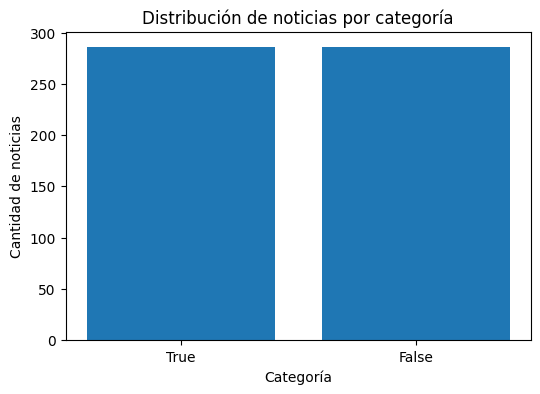

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(conteo_clases["CATEGORY"].astype(str), conteo_clases["cantidad"])
plt.title("Distribución de noticias por categoría")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de noticias")
plt.show()

## 4. Análisis de la variable TOPICS

In [ ]:
print("Valores únicos en TOPICS:")
print(df["TOPICS"].unique())

Valores únicos en TOPICS:
['Covid-19' 'Política' 'Sociedad' 'Internacional' 'Ciencia' 'Deporte'
 'Ambiental']


In [ ]:
conteo_topics = df["TOPICS"].value_counts().reset_index()
conteo_topics.columns = ["TOPICS", "cantidad"]

conteo_topics["porcentaje"] = (
    conteo_topics["cantidad"] / len(df) * 100
).round(2)

display(conteo_topics)

,TOPICS,cantidad,porcentaje
0,Covid-19,237,41.43
1,Sociedad,195,34.09
2,Política,107,18.71
3,Internacional,14,2.45
4,Ciencia,13,2.27
5,Ambiental,4,0.70
6,Deporte,2,0.35


In [ ]:
display(df[["TOPICS", "CATEGORY", "HEADLINE"]].head(10))

,TOPICS,CATEGORY,HEADLINE
0,Covid-19,True,Covid-19: mentiras que matan
1,Política,False,El Gobierno podrá acceder a las IPs de los móv...
2,Política,True,La comunidad musulmana catalana denuncia a Vox...
3,Política,False,None
4,Sociedad,True,El censo poblacional 2018 tendrá un costo de $...
5,Covid-19,False,None
6,Política,True,Fauci dice que fue sacado de contexto en un nu...
7,Covid-19,False,Franja naranja de estado de guerra en chile
8,Covid-19,False,Francia decreta el estado de emergencia y el t...
9,Covid-19,True,"Con 1.356 vacunas, Norte de Santander inició i..."


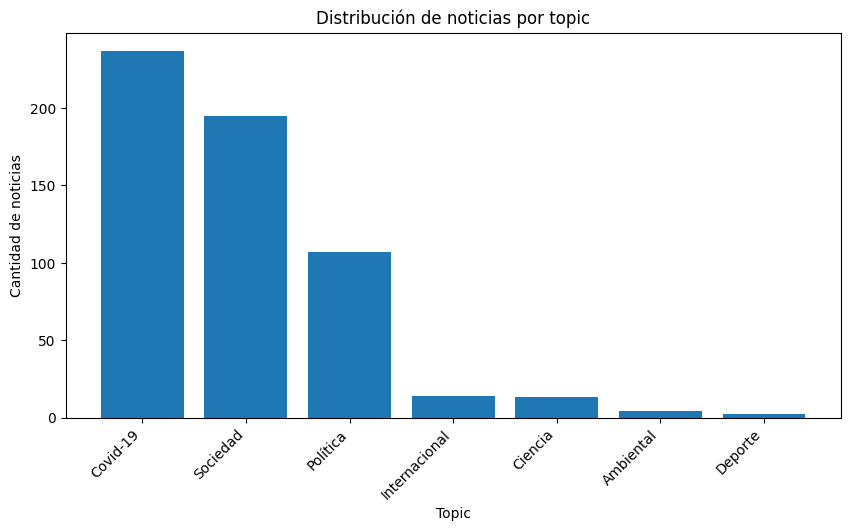

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(conteo_topics["TOPICS"].astype(str), conteo_topics["cantidad"])
plt.title("Distribución de noticias por topic")
plt.xlabel("Topic")
plt.ylabel("Cantidad de noticias")
plt.xticks(rotation=45, ha="right")
plt.show()

## Conclusiones de la etapa 4

En esta etapa se analizó la variable **`TOPICS`**, la cual representa el tema principal asociado a cada noticia del dataset. Esta variable es importante porque permite observar en qué áreas temáticas se concentra la mayor cantidad de noticias y, posteriormente, analizar si determinados temas presentan mayor presencia de noticias falsas o verdaderas.

El dataset contiene **7 temas diferentes**: `Covid-19`, `Sociedad`, `Política`, `Internacional`, `Ciencia`, `Ambiental` y `Deporte`.

| Topic         | Cantidad | Porcentaje |
| ------------- | -------: | ---------: |
| Covid-19      |      237 |     41.43% |
| Sociedad      |      195 |     34.09% |
| Política      |      107 |     18.71% |
| Internacional |       14 |      2.45% |
| Ciencia       |       13 |      2.27% |
| Ambiental     |        4 |      0.70% |
| Deporte       |        2 |      0.35% |

A partir de los resultados, se observa que la mayor parte de las noticias se concentra en tres temas principales: **Covid-19**, **Sociedad** y **Política**. El tema con mayor presencia es **Covid-19**, con **237 registros**, equivalente al **41.43%** del total. Le sigue **Sociedad**, con **195 noticias** (**34.09%**), y luego **Política**, con **107 registros** (**18.71%**).

En cambio, los temas **Internacional**, **Ciencia**, **Ambiental** y **Deporte** presentan una cantidad reducida de registros. Esto evidencia que el dataset no se encuentra balanceado a nivel temático, aunque sí se encontraba balanceado respecto a la variable objetivo `CATEGORY`.

El análisis de `TOPICS` muestra que el corpus está fuertemente concentrado en noticias relacionadas con **Covid-19**, **Sociedad** y **Política**, las cuales representan la mayor parte del dataset. Esta concentración temática resulta relevante porque puede influir en el aprendizaje del modelo, ya que los patrones lingüísticos más frecuentes podrían estar asociados principalmente a estos temas. Por ello, en etapas posteriores será necesario analizar la relación entre `TOPICS` y `CATEGORY` para identificar si ciertos temas presentan mayor proporción de noticias falsas o verdaderas.


## 5. Cruce entre Topics y Category

In [ ]:
tabla_topic_category = pd.crosstab(
    df["TOPICS"],
    df["CATEGORY"]
)

display(tabla_topic_category)

CATEGORY,False,True
TOPICS,,
Ambiental,2,2
Ciencia,7,6
Covid-19,119,118
Deporte,1,1
Internacional,7,7
Política,54,53
Sociedad,96,99


In [ ]:
tabla_topic_category_total = pd.crosstab(
    df["TOPICS"],
    df["CATEGORY"],
    margins=True,
    margins_name="Total"
)

display(tabla_topic_category_total)


CATEGORY,False,True,Total
TOPICS,,,
Ambiental,2,2,4
Ciencia,7,6,13
Covid-19,119,118,237
Deporte,1,1,2
Internacional,7,7,14
Política,54,53,107
Sociedad,96,99,195
Total,286,286,572


In [ ]:
tabla_topic_category_pct = pd.crosstab(
    df["TOPICS"],
    df["CATEGORY"],
    normalize="index"
) * 100

tabla_topic_category_pct = tabla_topic_category_pct.round(2)

display(tabla_topic_category_pct)

CATEGORY,False,True
TOPICS,,
Ambiental,50.00,50.00
Ciencia,53.85,46.15
Covid-19,50.21,49.79
Deporte,50.00,50.00
Internacional,50.00,50.00
Política,50.47,49.53
Sociedad,49.23,50.77


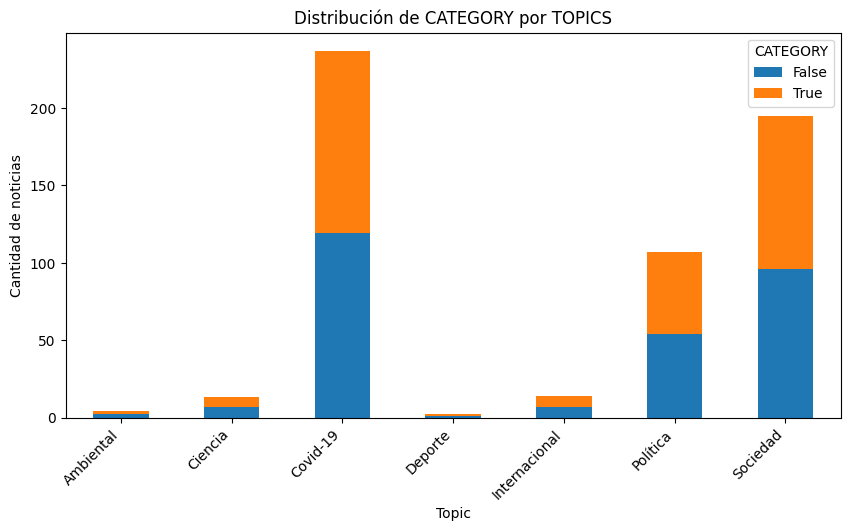

In [ ]:
tabla_topic_category.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Distribución de CATEGORY por TOPICS")
plt.xlabel("Topic")
plt.ylabel("Cantidad de noticias")
plt.xticks(rotation=45, ha="right")
plt.legend(title="CATEGORY")
plt.show()

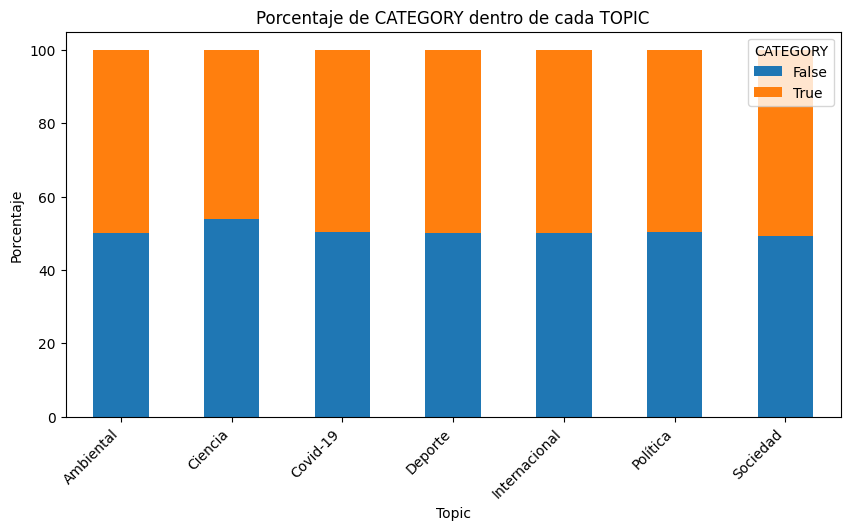

In [ ]:
tabla_topic_category_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Porcentaje de CATEGORY dentro de cada TOPIC")
plt.xlabel("Topic")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45, ha="right")
plt.legend(title="CATEGORY")
plt.show()

## Conclusion etapa 5

En esta etapa se analizó la relación entre la variable temática `TOPICS` y la variable objetivo `CATEGORY`, con el objetivo de identificar si existen diferencias en la proporción de noticias falsas y verdaderas según el tema.

Para ello, se construyó una tabla de contingencia que muestra la cantidad de noticias falsas (`False`) y verdaderas (`True`) dentro de cada categoría temática.

| Topic         | False | True | Total |
| ------------- | ----: | ---: | ----: |
| Ambiental     |     2 |    2 |     4 |
| Ciencia       |     7 |    6 |    13 |
| Covid-19      |   119 |  118 |   237 |
| Deporte       |     1 |    1 |     2 |
| Internacional |     7 |    7 |    14 |
| Política      |    54 |   53 |   107 |
| Sociedad      |    96 |   99 |   195 |

Asimismo, se calculó la proporción de cada categoría dentro de cada tema, obteniéndose los siguientes resultados:

| Topic         | False (%) | True (%) |
| ------------- | --------: | -------: |
| Ambiental     |     50.00 |    50.00 |
| Ciencia       |     53.85 |    46.15 |
| Covid-19      |     50.21 |    49.79 |
| Deporte       |     50.00 |    50.00 |
| Internacional |     50.00 |    50.00 |
| Política      |     50.47 |    49.53 |
| Sociedad      |     49.23 |    50.77 |

Los gráficos de barras apiladas permiten visualizar que, en todos los temas, la distribución entre noticias falsas y verdaderas es prácticamente uniforme.


El análisis de la relación entre `TOPICS` y `CATEGORY` muestra que la proporción de noticias falsas y verdaderas es **altamente equilibrada en todos los temas**, con valores cercanos al 50% en cada categoría. Esto indica que no existe un sesgo evidente de desinformación asociado a un tema específico dentro del dataset.

En consecuencia, se puede inferir que la variable `TOPICS` no presenta una influencia significativa en la probabilidad de que una noticia sea falsa o verdadera en este corpus. Este hallazgo sugiere que el modelo de clasificación deberá basarse principalmente en características lingüísticas y textuales del contenido de las noticias, en lugar de depender del tema como factor determinante.


## 6. Calidad de datos

In [ ]:
nulos = df.isnull().sum().reset_index()
nulos.columns = ["columna", "nulos"]

nulos["porcentaje"] = (nulos["nulos"] / len(df) * 100).round(2)

display(nulos)

,columna,nulos,porcentaje
0,ID,0,0.00
1,CATEGORY,0,0.00
2,TOPICS,0,0.00
3,SOURCE,7,1.22
4,HEADLINE,72,12.59
5,TEXT,0,0.00
6,LINK,3,0.52


In [ ]:
duplicados_completos = df.duplicated().sum()
print("Duplicados completos:", duplicados_completos)

Duplicados completos: 0


In [ ]:
duplicados_texto = df["TEXT"].duplicated().sum()
print("Duplicados en TEXT:", duplicados_texto)

Duplicados en TEXT: 0


In [ ]:
textos_vacios = df["TEXT"].astype(str).str.strip().eq("").sum()
print("Textos vacíos:", textos_vacios)

Textos vacíos: 0


In [ ]:
headlines_nulos = df["HEADLINE"].isnull().sum()
headlines_vacios = df["HEADLINE"].astype(str).str.strip().eq("").sum()

print("HEADLINE nulos:", headlines_nulos)
print("HEADLINE vacíos:", headlines_vacios)

HEADLINE nulos: 72
HEADLINE vacíos: 0


In [ ]:
print("Ejemplos con HEADLINE nulo:")
display(df[df["HEADLINE"].isnull()][["CATEGORY", "TOPICS", "HEADLINE", "TEXT"]].head(10))

Ejemplos con HEADLINE nulo:


,CATEGORY,TOPICS,HEADLINE,TEXT
3,False,Política,None,Se han dado a conocer los datos electorales pr...
5,False,Covid-19,None,Boooomm\nMUJERES VACUNADAS DE COVID ESTÁN MOST...
15,False,Sociedad,None,COMUNICADO DEL VICEPRESIDENTE DE FEDERACIÓN AJ...
31,False,Política,None,Lean (y vean la imagen) con mucha atención:\n\...
35,False,Ciencia,None,Bill Gates no es quien creen que es.\nEn prime...
54,False,Covid-19,None,*Una gran noticia! Vacuna contra el virus Coro...
55,False,Covid-19,None,"Anthony Fauci, el epidemiólogo de La Casa Blan..."
64,False,Covid-19,None,México fue el primero en activar medidas contr...
73,False,Sociedad,None,"Esto no es #California ni Estados Unidos, esto..."
74,False,Covid-19,None,MASCARILLAS.... PREFERENTEMENTE PARA CARNAVAL ...


In [ ]:
print("Ejemplos con TEXT nulo o vacío:")
display(df[
    df["TEXT"].isnull() | df["TEXT"].astype(str).str.strip().eq("")
][["CATEGORY", "TOPICS", "HEADLINE", "TEXT"]])

Ejemplos con TEXT nulo o vacío:


,CATEGORY,TOPICS,HEADLINE,TEXT


## Conclusion etapa 6

En esta etapa se evaluó la calidad del dataset con el objetivo de identificar posibles problemas que puedan afectar el rendimiento del modelo, tales como valores nulos, registros duplicados o inconsistencias en las variables.

Se realizó un análisis de valores faltantes por columna, obteniéndose los siguientes resultados:

| Columna  | Nulos | Porcentaje |
| -------- | ----: | ---------: |
| ID       |     0 |      0.00% |
| CATEGORY |     0 |      0.00% |
| TOPICS   |     0 |      0.00% |
| SOURCE   |     7 |      1.22% |
| HEADLINE |    72 |     12.59% |
| TEXT     |     0 |      0.00% |
| LINK     |     3 |      0.52% |

Se observa que la mayoría de las columnas no presentan valores nulos. Sin embargo, la variable **`HEADLINE` presenta 72 valores nulos**, lo que representa aproximadamente el **12.59% del dataset**. Por otro lado, las variables `SOURCE` y `LINK` presentan una cantidad mínima de valores faltantes, con porcentajes inferiores al 2%.

En cuanto a la duplicidad de los datos, se verificó que no existen **registros duplicados completos**, ni duplicados en la columna `TEXT`, lo cual indica que cada noticia es única dentro del dataset.

Asimismo, se comprobó que no existen textos vacíos en la columna `TEXT`, lo cual es fundamental dado que esta variable constituye la principal fuente de información para el modelo de clasificación.

El análisis de la variable `HEADLINE` mostró que los valores faltantes corresponden a registros donde el titular de la noticia no está disponible (representados como `None`). No obstante, estos registros sí contienen información en la columna `TEXT`, por lo que no necesariamente deben ser eliminados.

El dataset presenta en general una **buena calidad de datos**, ya que no contiene duplicados ni textos vacíos, y la variable principal `TEXT` se encuentra completa en todos los registros. La principal observación corresponde a la variable `HEADLINE`, que presenta un **12.59% de valores nulos**.

Dado que el objetivo del proyecto es clasificar noticias en función de su contenido textual, y considerando que la columna `TEXT` no presenta valores faltantes, se determina que no es necesario eliminar estos registros. En cambio, se evaluará la posibilidad de utilizar únicamente el contenido de `TEXT` como variable principal de entrada para el modelo, o complementar con `HEADLINE` en los casos disponibles.

Las columnas `SOURCE` y `LINK`, debido a su bajo nivel de completitud y a que no aportan directamente al objetivo de clasificación textual, podrán ser descartadas en etapas posteriores de preparación de datos.


## 7. Análisis de longitud de texto

In [ ]:
df_eda = df.copy()

In [ ]:
df_eda["TEXT_CLEAN_EDA"] = (
    df_eda["TEXT"]
    .astype(str)
    .str.replace(r"[\n\t\r]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_eda["TEXT_NUM_CARACTERES"] = df_eda["TEXT_CLEAN_EDA"].str.len()

df_eda["TEXT_NUM_PALABRAS"] = df_eda["TEXT_CLEAN_EDA"].str.split().str.len()

In [ ]:
display(df_eda[[
    "CATEGORY",
    "TOPICS",
    "TEXT_NUM_CARACTERES",
    "TEXT_NUM_PALABRAS"
]].head())

,CATEGORY,TOPICS,TEXT_NUM_CARACTERES,TEXT_NUM_PALABRAS
0,True,Covid-19,4568,786
1,False,Política,1803,288
2,True,Política,4118,658
3,False,Política,1232,209
4,True,Sociedad,1717,280


In [ ]:
print("Estadísticas generales - caracteres:")
display(df_eda["TEXT_NUM_CARACTERES"].describe())

Estadísticas generales - caracteres:


,TEXT_NUM_CARACTERES
count,572.000000
mean,3174.578671
std,2669.383628
min,261.000000
25%,1512.000000
50%,2409.500000
75%,3975.250000
max,25663.000000


In [ ]:
print("Estadísticas generales - palabras:")
display(df_eda["TEXT_NUM_PALABRAS"].describe())

Estadísticas generales - palabras:


,TEXT_NUM_PALABRAS
count,572.000000
mean,521.277972
std,438.023468
min,47.000000
25%,250.000000
50%,398.500000
75%,653.000000
max,4006.000000


In [ ]:
print("Longitud en caracteres por CATEGORY:")
display(df_eda.groupby("CATEGORY")["TEXT_NUM_CARACTERES"].describe())

Longitud en caracteres por CATEGORY:


,count,mean,std,min,25%,50%,75%,max
CATEGORY,,,,,,,,
False,286.0,2471.699301,2549.337239,261.0,1158.5,1804.5,2957.75,25663.0
True,286.0,3877.458042,2604.909581,540.0,2002.0,3366.0,5062.00,23900.0


In [ ]:
print("Longitud en palabras por CATEGORY:")
display(df_eda.groupby("CATEGORY")["TEXT_NUM_PALABRAS"].describe())

Longitud en palabras por CATEGORY:


,count,mean,std,min,25%,50%,75%,max
CATEGORY,,,,,,,,
False,286.0,408.423077,416.491729,47.0,199.00,301.0,480.5,4003.0
True,286.0,634.132867,430.552126,84.0,337.25,545.0,817.5,4006.0


In [ ]:
promedio_palabras_category = (
    df_eda.groupby("CATEGORY")["TEXT_NUM_PALABRAS"]
    .mean()
    .round(2)
    .reset_index()
)

display(promedio_palabras_category)

,CATEGORY,TEXT_NUM_PALABRAS
0,False,408.42
1,True,634.13


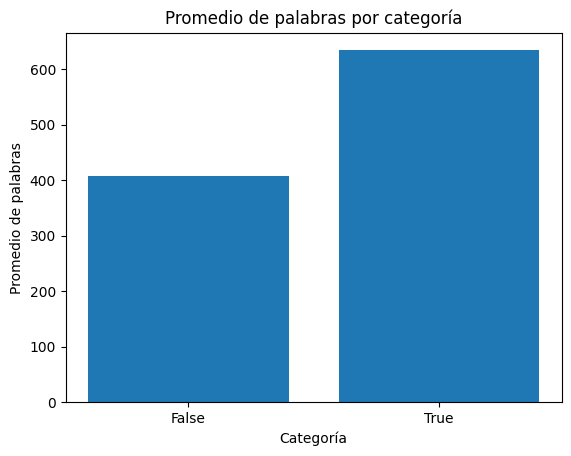

In [ ]:
plt.figure()
plt.bar(
    promedio_palabras_category["CATEGORY"].astype(str),
    promedio_palabras_category["TEXT_NUM_PALABRAS"]
)
plt.title("Promedio de palabras por categoría")
plt.xlabel("Categoría")
plt.ylabel("Promedio de palabras")
plt.show()


<Figure size 640x480 with 0 Axes>

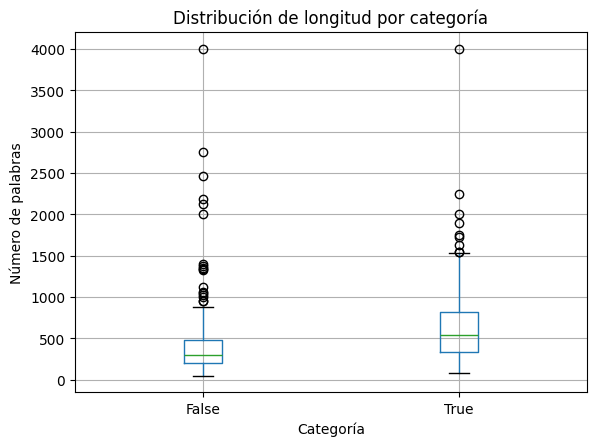

In [ ]:
plt.figure()
df_eda.boxplot(
    column="TEXT_NUM_PALABRAS",
    by="CATEGORY"
)
plt.title("Distribución de longitud por categoría")
plt.suptitle("")
plt.xlabel("Categoría")
plt.ylabel("Número de palabras")
plt.show()

In [ ]:
print("Noticias con menos de 20 palabras:")
display(df_eda[df_eda["TEXT_NUM_PALABRAS"] < 20][[
    "CATEGORY", "TOPICS", "HEADLINE", "TEXT_NUM_PALABRAS"
]])


Noticias con menos de 20 palabras:


,CATEGORY,TOPICS,HEADLINE,TEXT_NUM_PALABRAS


In [ ]:
print("Top 10 textos más largos:")
display(df_eda.sort_values("TEXT_NUM_PALABRAS", ascending=False)[[
    "CATEGORY", "TOPICS", "HEADLINE", "TEXT_NUM_PALABRAS"
]].head(10))

Top 10 textos más largos:


,CATEGORY,TOPICS,HEADLINE,TEXT_NUM_PALABRAS
497,True,Sociedad,Tres veces secuestrada: así funciona el negoci...,4006
125,False,Covid-19,Enorme escándalo descubierto: La vacuna COVID-...,4003
163,False,Covid-19,"Exvicepresidente de Pﬁzer: ""No hay necesidad d...",2749
251,False,Política,Los papeles del 23F salen a la luz: 'El Rey Ju...,2470
306,True,Política,"""Esto antes era impensable"": la creciente preo...",2243
80,False,Política,"Españoles, alerta, la empresa que procesará la...",2188
220,False,Covid-19,Ana María Oliva: ’La gente no muere por Covid’,2123
46,True,Política,La política tóxica contamina a España,2004
412,False,Covid-19,Noticia DE ÚLTIMA HORA: Santiago Niño Becerra ...,2004
389,True,Covid-19,Tratamiento del coronavirus: el extraordinario...,1897


## Conclusion etapa 7

Antes de analizar la longitud de los textos, se creó una copia del dataset para no modificar el conjunto original. Sobre esta copia se aplicó una limpieza básica orientada al análisis exploratorio, reemplazando saltos de línea, tabulaciones y espacios múltiples por espacios simples. Esta limpieza no altera el contenido semántico de las noticias, pero permite calcular métricas de longitud de forma más consistente.

Se calcularon dos métricas principales: número de palabras y número de caracteres por noticia. A nivel general, el dataset presenta un promedio de **521.28 palabras por noticia**, con una mediana de **398.5 palabras**. La noticia más corta contiene **47 palabras**, mientras que la más extensa alcanza **4006 palabras**, lo que evidencia una alta variabilidad en la extensión de los textos.

Al comparar por categoría, se observa una diferencia importante entre noticias falsas y verdaderas. Las noticias clasificadas como **False** presentan un promedio de **408.42 palabras**, mientras que las noticias clasificadas como **True** alcanzan un promedio de **634.13 palabras**. Esta diferencia también se observa en la mediana: las noticias falsas tienen una mediana de **301 palabras**, mientras que las verdaderas presentan una mediana de **545 palabras**.

| Categoría | Promedio de palabras | Mediana | Mínimo | Máximo |
| --------- | -------------------: | ------: | -----: | -----: |
| False     |               408.42 |   301.0 |     47 |   4003 |
| True      |               634.13 |   545.0 |     84 |   4006 |

En cuanto a la longitud en caracteres, las noticias falsas tienen un promedio de **2471.70 caracteres**, mientras que las verdaderas presentan un promedio de **3877.46 caracteres**. Esto confirma que, en este dataset, las noticias verdaderas tienden a ser más extensas que las falsas.

| Categoría | Promedio de caracteres | Mediana | Mínimo | Máximo |
| --------- | ---------------------: | ------: | -----: | -----: |
| False     |                2471.70 |  1804.5 |    261 |  25663 |
| True      |                3877.46 |  3366.0 |    540 |  23900 |


El análisis de longitud muestra que las noticias verdaderas son, en promedio, más extensas que las noticias falsas, tanto en número de palabras como en número de caracteres. Este patrón sugiere que la longitud del texto podría ser una característica útil para diferenciar entre ambas categorías. Además, se identificó la presencia de valores atípicos en ambas categorías, representados por noticias con una extensión considerablemente superior al resto del conjunto de datos. Por ello, la longitud del texto debe analizarse con cautela y no debe considerarse como una variable suficiente por sí sola para clasificar una noticia como falsa o verdadera.


## 8. Palabras más frecuentes en TEXT

In [ ]:
nlp = spacy.load("es_core_news_sm")

In [ ]:
def limpiar_texto_spacy_lemma(texto):
    texto = str(texto)
    texto = re.sub(r"[\n\t\r]+", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    doc = nlp(texto)
    tokens_limpios = []
    for token in doc:
        if token.is_stop:
            continue
        if token.is_punct or token.is_space:
            continue
        if token.like_url or token.like_email:
            continue
        if token.is_digit or token.like_num:
            continue
        if len(token.text.strip()) <= 2:
            continue
        if token.pos_ == "PROPN":
            palabra = token.text.strip()
        else:
            palabra = token.lemma_.strip().lower()

        palabra = re.sub(r"[^A-Za-zÁÉÍÓÚáéíóúÑñÜü]", "", palabra)
        if len(palabra) <= 2:
          continue
        tokens_limpios.append(palabra)
    return tokens_limpios


In [ ]:
df_words = df_eda.copy()

In [ ]:
todas_palabras = []

for texto in df_words["TEXT_CLEAN_EDA"]:
    todas_palabras.extend(limpiar_texto_spacy_lemma(texto))

frecuencia_general = Counter(todas_palabras)

top_general = pd.DataFrame(
    frecuencia_general.most_common(20),
    columns=["palabra", "frecuencia"]
)

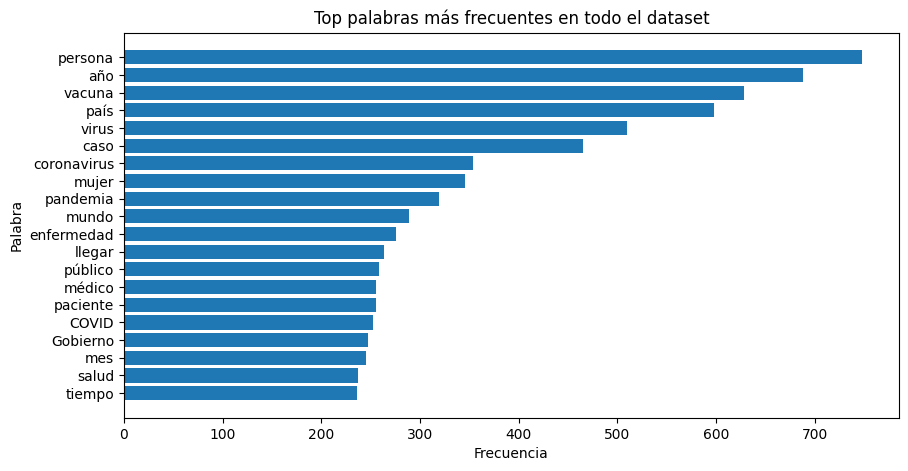

In [ ]:
plt.figure(figsize=(10, 5))

plt.barh(
    top_general["palabra"],
    top_general["frecuencia"]
)

plt.title("Top palabras más frecuentes en todo el dataset")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")

plt.gca().invert_yaxis()

plt.show()

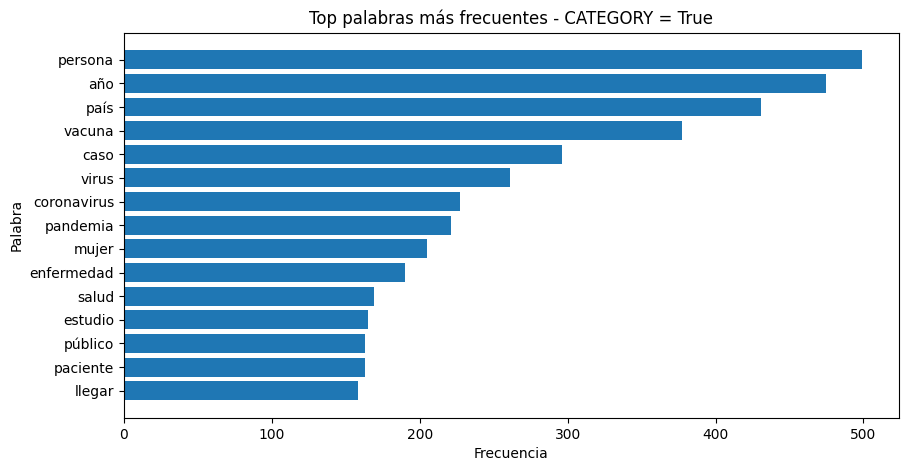

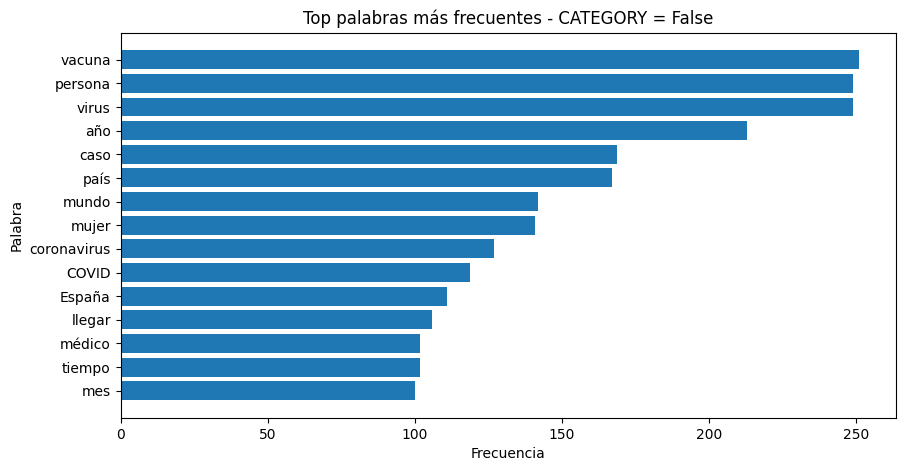

In [ ]:
for categoria in df_words["CATEGORY"].unique():

    palabras_categoria = []

    textos_categoria = df_words[df_words["CATEGORY"] == categoria]["TEXT_CLEAN_EDA"]

    for texto in textos_categoria:
        palabras_categoria.extend(limpiar_texto_spacy_lemma(texto))

    frecuencia_categoria = Counter(palabras_categoria)

    top_categoria = pd.DataFrame(
        frecuencia_categoria.most_common(15),
        columns=["palabra", "frecuencia"]
    )

    plt.figure(figsize=(10, 5))

    plt.barh(
        top_categoria["palabra"],
        top_categoria["frecuencia"]
    )

    plt.title(f"Top palabras más frecuentes - CATEGORY = {categoria}")
    plt.xlabel("Frecuencia")
    plt.ylabel("Palabra")

    plt.gca().invert_yaxis()

    plt.show()

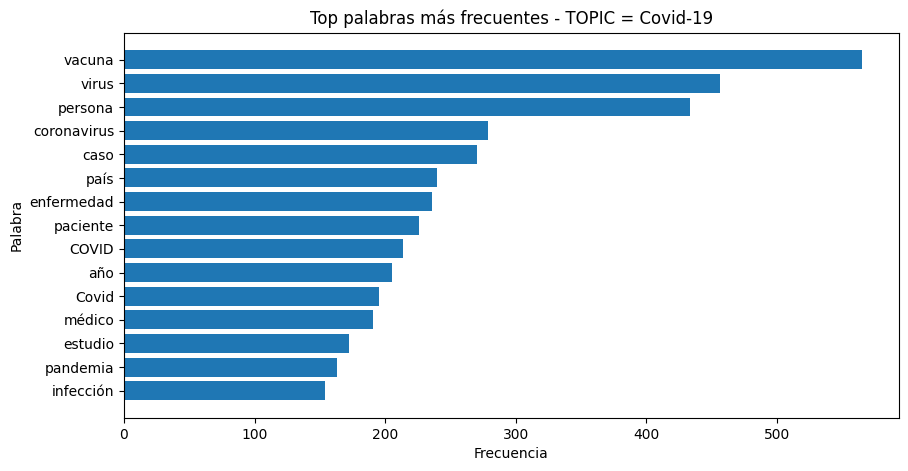

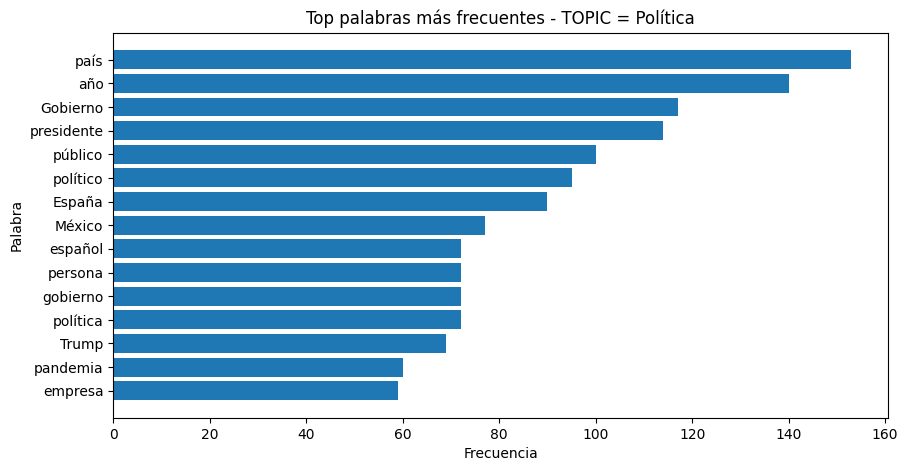

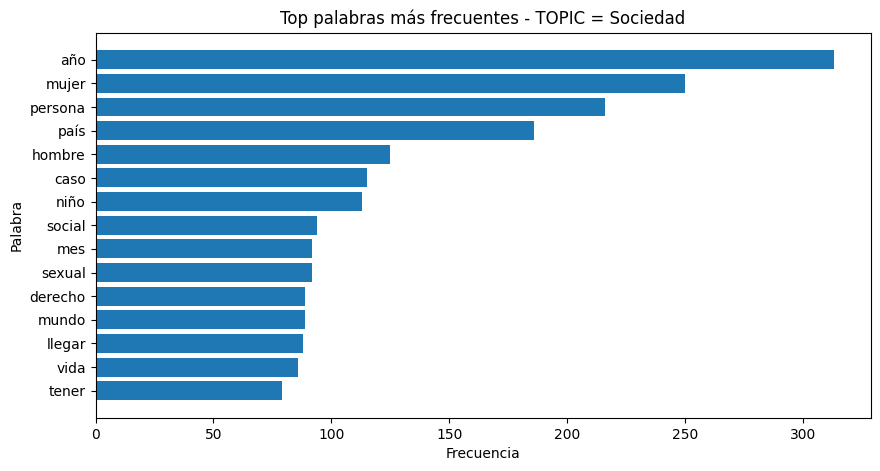

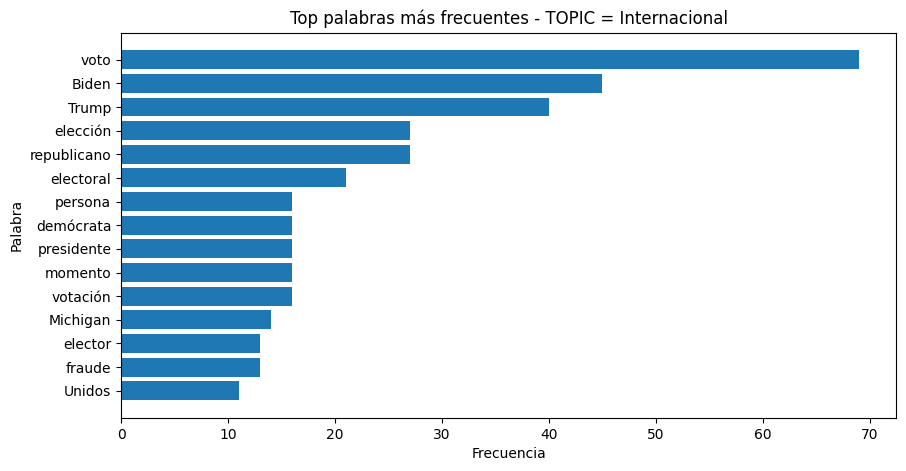

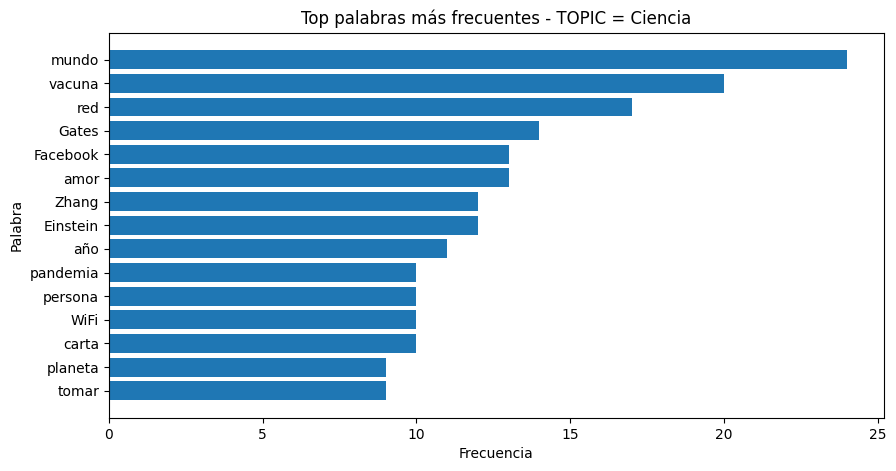

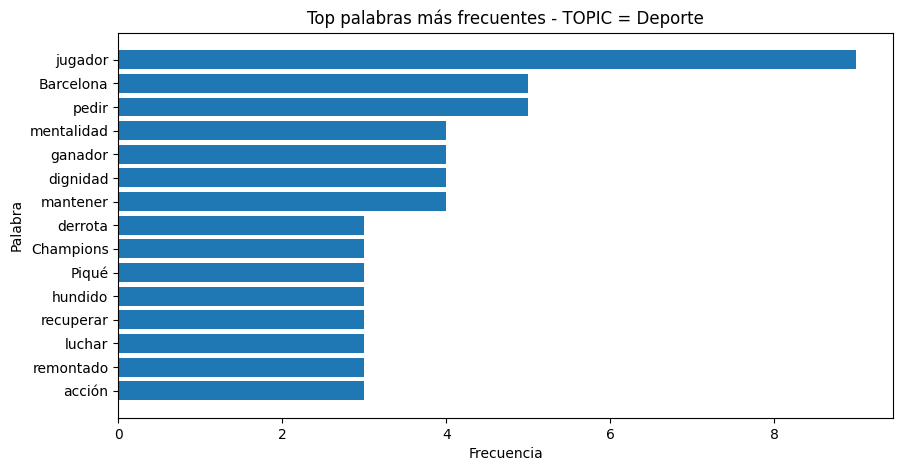

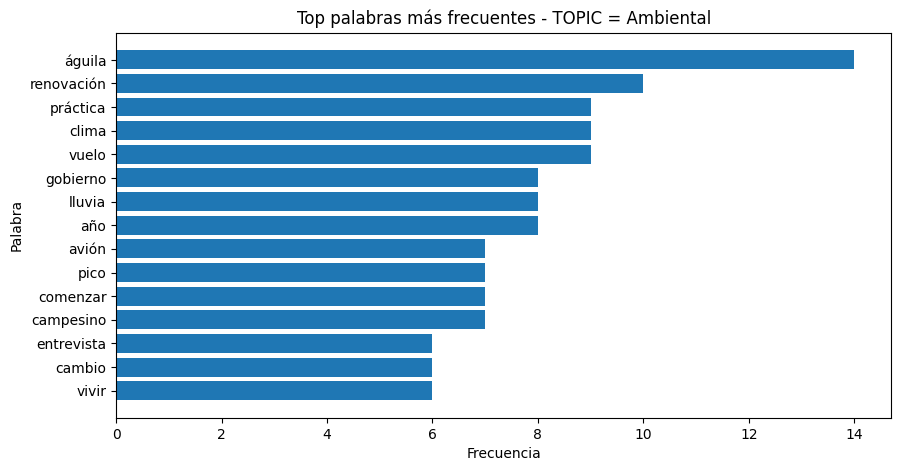

In [ ]:
for topic in df_words["TOPICS"].unique():

    palabras_topic = []

    textos_topic = df_words[df_words["TOPICS"] == topic]["TEXT_CLEAN_EDA"]

    for texto in textos_topic:
        palabras_topic.extend(limpiar_texto_spacy_lemma(texto))

    frecuencia_topic = Counter(palabras_topic)

    top_topic = pd.DataFrame(
        frecuencia_topic.most_common(15),
        columns=["palabra", "frecuencia"]
    )

    plt.figure(figsize=(10, 5))

    plt.barh(
        top_topic["palabra"],
        top_topic["frecuencia"]
    )

    plt.title(f"Top palabras más frecuentes - TOPIC = {topic}")
    plt.xlabel("Frecuencia")
    plt.ylabel("Palabra")

    plt.gca().invert_yaxis()
    plt.show()

## Conclusiones etapa 8

En esta etapa se analizaron las palabras más frecuentes del corpus con el objetivo de identificar patrones lingüísticos generales y diferencias iniciales entre noticias falsas y verdaderas. Para ello, se utilizó una limpieza específica para el análisis textual, aplicando eliminación de stopwords mediante spaCy y lematización para agrupar variantes de una misma palabra, como “mujeres” y “mujer”, o “casos” y “caso”.

A nivel general, las palabras más frecuentes del dataset fueron **persona**, **año**, **vacuna**, **país**, **virus**, **caso**, **coronavirus**, **mujer**, **pandemia** y **mundo**. Esto indica que el corpus se encuentra fuertemente asociado a temas sociales, sanitarios y políticos, lo cual coincide con la distribución temática observada anteriormente, donde predominaban las noticias de **Covid-19**, **Sociedad** y **Política**.

Al comparar por categoría, se observa que las noticias clasificadas como **False** presentan con mayor frecuencia términos como **vacuna**, **persona**, **virus**, **año**, **caso**, **país**, **mundo**, **mujer**, **coronavirus** y **COVID**. Por otro lado, las noticias clasificadas como **True** muestran como términos más frecuentes **persona**, **año**, **país**, **vacuna**, **caso**, **virus**, **coronavirus**, **pandemia**, **mujer** y **enfermedad**.

Estos resultados muestran que ambas categorías comparten varios términos frecuentes, especialmente aquellos relacionados con salud pública y contexto social. Sin embargo, en las noticias falsas se observa una mayor presencia relativa de términos vinculados directamente a **vacuna**, **virus** y **COVID**, lo que sugiere una fuerte concentración de desinformación en contenidos sanitarios dentro del corpus. En las noticias verdaderas, en cambio, aparecen términos más generales y descriptivos como **persona**, **año**, **país**, **pandemia** y **enfermedad**, lo cual podría reflejar una redacción más contextualizada o informativa.

El análisis por topic refuerza esta interpretación. En el tema **Covid-19**, predominan palabras como **vacuna**, **virus**, **persona**, **coronavirus**, **caso**, **enfermedad**, **paciente**, **COVID** y **médico**. En **Política**, destacan términos como **país**, **año**, **Gobierno**, **presidente**, **público**, **político**, **España**, **México** y **Trump**. En **Sociedad**, aparecen términos como **año**, **mujer**, **persona**, **país**, **hombre**, **caso**, **niño**, **social** y **derecho**. Esto evidencia que las palabras más frecuentes están relacionadas directamente con el contenido temático de cada grupo de noticias.

El análisis de palabras frecuentes permitió identificar que el corpus está dominado por términos asociados a salud pública, sociedad y política. Asimismo, se observó que las noticias falsas y verdaderas comparten muchas palabras frecuentes, por lo que la frecuencia simple de términos no parece ser suficiente por sí sola para separar ambas clases. No obstante, sí permite reconocer patrones temáticos relevantes y confirmar que conceptos como **vacuna**, **virus**, **COVID**, **persona**, **país** y **año** tienen un peso importante dentro del corpus.

Por ello, en etapas posteriores será necesario aplicar técnicas de representación textual más avanzadas, como **TF-IDF**, para identificar no solo las palabras más repetidas, sino aquellas que aportan mayor capacidad discriminativa para el modelo de clasificación.


## 9. Análisis de patrones estilométricos.
EL objetivo es revisar señales de estilo que pueden diferenciar noticias falsas y verdaderas, como uso de mayúsculas, signos de exclamación, signos de interrogación, números y URLs.



In [ ]:
df_style = df_eda.copy()

In [ ]:
def contar_exclamaciones(texto):
    return str(texto).count("!")

def contar_interrogaciones(texto):
    return str(texto).count("?")

def contar_mayusculas(texto):
    return sum(1 for c in str(texto) if c.isupper())

def contar_digitos(texto):
    return sum(1 for c in str(texto) if c.isdigit())

def contar_urls(texto):
      return len(re.findall(r"http\S+|www\S+", str(texto)))

In [ ]:
df_style["NUM_EXCLAMACIONES"] = df_style["TEXT"].apply(contar_exclamaciones)
df_style["NUM_INTERROGACIONES"] = df_style["TEXT"].apply(contar_interrogaciones)
df_style["NUM_MAYUSCULAS"] = df_style["TEXT"].apply(contar_mayusculas)
df_style["NUM_DIGITOS"] = df_style["TEXT"].apply(contar_digitos)
df_style["NUM_URLS"] = df_style["TEXT"].apply(contar_urls)

In [ ]:
df_style["PROP_MAYUSCULAS"] = (
    df_style["NUM_MAYUSCULAS"] / df_style["TEXT_NUM_CARACTERES"]
).round(4)

In [ ]:
display(df_style[[
    "CATEGORY",
    "TOPICS",
    "NUM_EXCLAMACIONES",
    "NUM_INTERROGACIONES",
    "NUM_MAYUSCULAS",
    "PROP_MAYUSCULAS",
    "NUM_DIGITOS",
    "NUM_URLS"
]].head())

,CATEGORY,TOPICS,NUM_EXCLAMACIONES,NUM_INTERROGACIONES,NUM_MAYUSCULAS,PROP_MAYUSCULAS,NUM_DIGITOS,NUM_URLS
0,True,Covid-19,0,0,61,0.0134,20,0
1,False,Política,0,0,50,0.0277,0,0
2,True,Política,0,0,64,0.0155,32,0
3,False,Política,0,0,21,0.0170,6,0
4,True,Sociedad,0,0,29,0.0169,23,0


In [ ]:
resumen_estilo = df_style.groupby("CATEGORY")[[
    "NUM_EXCLAMACIONES",
    "NUM_INTERROGACIONES",
    "NUM_MAYUSCULAS",
    "PROP_MAYUSCULAS",
    "NUM_DIGITOS",
    "NUM_URLS"
]].mean().round(4)

display(resumen_estilo)


,NUM_EXCLAMACIONES,NUM_INTERROGACIONES,NUM_MAYUSCULAS,PROP_MAYUSCULAS,NUM_DIGITOS,NUM_URLS
CATEGORY,,,,,,
False,0.6503,1.4860,82.8182,0.0390,17.3252,0.021
True,0.1084,0.6189,85.9615,0.0228,28.4476,0.021


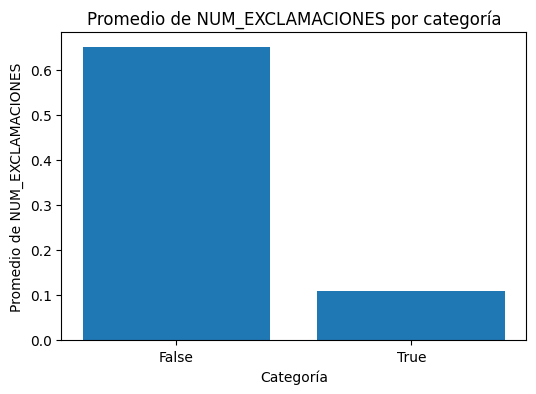

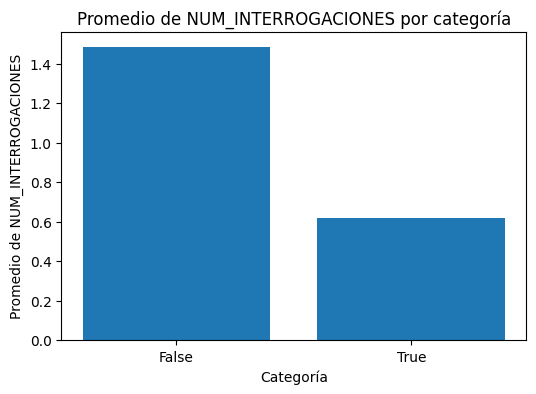

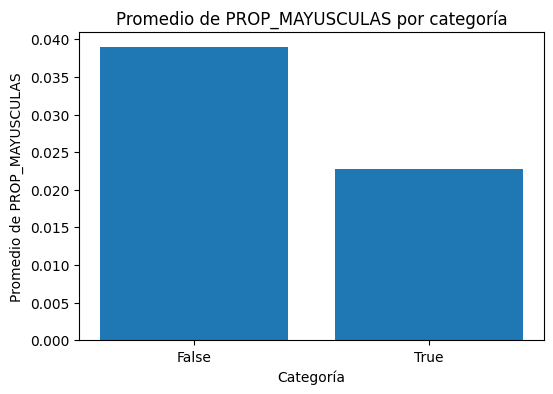

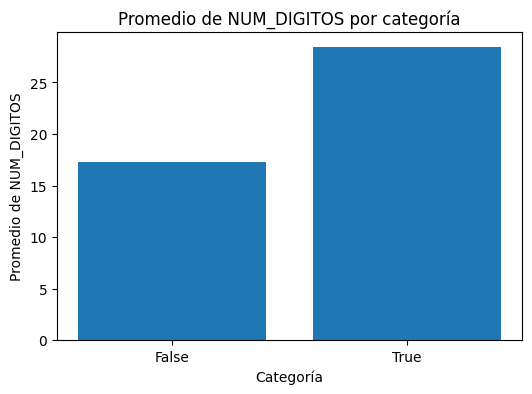

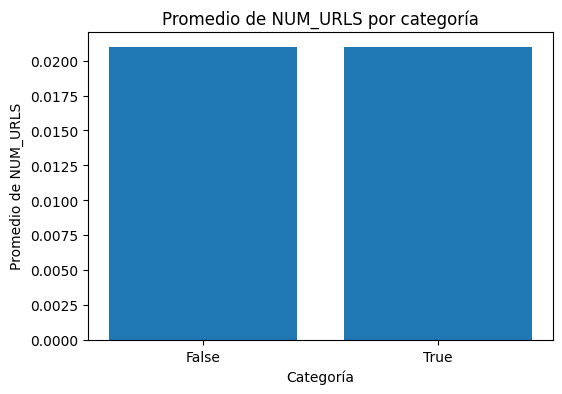

In [ ]:
variables_estilo = [
    "NUM_EXCLAMACIONES",
    "NUM_INTERROGACIONES",
    "PROP_MAYUSCULAS",
    "NUM_DIGITOS",
    "NUM_URLS"
]

for variable in variables_estilo:
    promedio_var = (
        df_style.groupby("CATEGORY")[variable]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(6, 4))
    plt.bar(
        promedio_var["CATEGORY"].astype(str),
        promedio_var[variable]
    )
    plt.title(f"Promedio de {variable} por categoría")
    plt.xlabel("Categoría")
    plt.ylabel(f"Promedio de {variable}")
    plt.show()


In [ ]:
print("Top 10 noticias con más exclamaciones:")
display(df_style.sort_values("NUM_EXCLAMACIONES", ascending=False)[[
    "CATEGORY", "TOPICS", "HEADLINE", "NUM_EXCLAMACIONES", "TEXT"
]].head(10))


Top 10 noticias con más exclamaciones:


,CATEGORY,TOPICS,HEADLINE,NUM_EXCLAMACIONES,TEXT
251,False,Política,Los papeles del 23F salen a la luz: 'El Rey Ju...,26,"Aquella mañana llegué algo tarde a ""Río Frío"" ..."
240,False,Covid-19,None,16,"Los médicos italianos, desobedecieron la ley m..."
83,False,Covid-19,None,14,ATENCIÓN ESTO NO ES UN JUEGO!!!la vacunaa es ...
530,False,Sociedad,Miles de niños hambrientos y terriblemente mal...,12,"En este momento y desde la semana pasada, mile..."
235,False,Política,None,12,¡¡ESTA LA PURA VERDAD!!\n\n¡¡NO ES NECESARIO V...
412,False,Covid-19,Noticia DE ÚLTIMA HORA: Santiago Niño Becerra ...,9,(EL MUNDO) La semana pasada en el programa de ...
187,False,Covid-19,None,8,MÁS EVIDENCIAS DEL CORONA-FRAUDE!!! \nEn un No...
31,False,Política,None,8,Lean (y vean la imagen) con mucha atención:\n\...
134,True,Sociedad,Cómo los islandeses aprendieron a comer pescad...,5,"Una salchicha de hígado curada en suero agrio,..."
560,False,Ciencia,Están activando el 5G en celulares Android con...,4,Ya están activando el 5G en los celulares andr...


In [ ]:
print("Top 10 noticias con mayor proporción de mayúsculas:")
display(df_style.sort_values("PROP_MAYUSCULAS", ascending=False)[[
    "CATEGORY", "TOPICS", "HEADLINE", "PROP_MAYUSCULAS", "TEXT"
]].head(10))

Top 10 noticias con mayor proporción de mayúsculas:


,CATEGORY,TOPICS,HEADLINE,PROP_MAYUSCULAS,TEXT
235,False,Política,None,0.7730,¡¡ESTA LA PURA VERDAD!!\n\n¡¡NO ES NECESARIO V...
239,False,Covid-19,None,0.6862,¡¡¡ATENCIÓN PERÚ!!! QUIENES VENDEN : LA IVERME...
373,False,Sociedad,None,0.6103,OS LO VOY A PONER EN MAYÚSCULAS POR SI YA VAIS...
187,False,Covid-19,None,0.3580,MÁS EVIDENCIAS DEL CORONA-FRAUDE!!! \nEn un No...
211,False,Ambiental,Meteorólogos Españoles Denuncian ante la UE qu...,0.2981,Muchos pensábamos en ello y los medios oficial...
68,False,Covid-19,Venezuela será el ‘primer país occidental en r...,0.2777,"AHORA SI, OFICIAL, HACE 2 HORAS Y MEDIA, POR C..."
445,False,Covid-19,None,0.1532,?? *ÚLTIMA HORA* ??\n\n*NO son necesarios los ...
198,False,Covid-19,Las mascarillas bien manipuladas no permiten u...,0.1477,FUE TAN FÁCIL CONVENCER A CASI UN MUNDO ENTERO...
280,False,Covid-19,None,0.1237,#PREFIERO INYECTARME AGUA QUE LAS VACUNITAS DE...
5,False,Covid-19,None,0.1207,Boooomm\nMUJERES VACUNADAS DE COVID ESTÁN MOST...


## Conclusiones etapa 9

En esta etapa se analizaron características estilométricas del texto, como el número de exclamaciones, interrogaciones, mayúsculas, proporción de mayúsculas, dígitos y URLs. El objetivo fue identificar si existen señales de estilo que puedan diferenciar, aunque sea de manera inicial, las noticias falsas de las verdaderas.

| Categoría | Exclamaciones | Interrogaciones | Mayúsculas | Proporción mayúsculas | Dígitos |  URLs |
| --------- | ------------: | --------------: | ---------: | --------------------: | ------: | ----: |
| False     |        0.6503 |          1.4860 |    82.8182 |                0.0390 | 17.3252 | 0.021 |
| True      |        0.1084 |          0.6189 |    85.9615 |                0.0228 | 28.4476 | 0.021 |

Los resultados muestran que, en general, los promedios de varias características estilométricas son bajos. Por ejemplo, el promedio de exclamaciones es menor a 1 en ambas categorías, y el promedio de URLs es prácticamente igual y muy reducido. Esto indica que estos elementos no aparecen de forma masiva en el corpus y, por lo tanto, **no constituyen patrones altamente significativos por sí solos** para clasificar una noticia como falsa o verdadera.

Sin embargo, incluso con valores bajos, se observan diferencias interesantes entre ambas clases. Las noticias falsas presentan un mayor promedio de **exclamaciones** e **interrogaciones** que las noticias verdaderas. En particular, las noticias falsas registran un promedio de **0.6503 exclamaciones**, mientras que las verdaderas solo alcanzan **0.1084**. Del mismo modo, las noticias falsas presentan **1.4860 interrogaciones** en promedio, frente a **0.6189** en las verdaderas.

También se observa que las noticias falsas tienen una mayor **proporción de mayúsculas** (**0.0390**) en comparación con las noticias verdaderas (**0.0228**). Esto puede sugerir que ciertos textos falsos tienden a utilizar un estilo más enfático, llamativo o emocional. No obstante, debido a que la proporción sigue siendo baja, este patrón debe interpretarse como una señal complementaria y no como una característica determinante.

Por otro lado, las noticias verdaderas presentan un mayor promedio de **dígitos** (**28.4476**) frente a las noticias falsas (**17.3252**). Esto puede estar asociado a una mayor presencia de fechas, cifras, cantidades, porcentajes o referencias numéricas en textos informativos. En cambio, la variable relacionada con URLs no muestra diferencias entre ambas categorías, ya que ambas presentan el mismo promedio (**0.021**).

El análisis estilométrico muestra que las características de estilo no tienen una presencia suficientemente alta como para ser consideradas variables decisivas dentro del dataset. Sin embargo, los resultados sí permiten identificar diferencias relevantes: las noticias falsas presentan mayor uso relativo de exclamaciones, interrogaciones y mayúsculas, mientras que las noticias verdaderas presentan mayor presencia de dígitos.

Por ello, estos patrones no deben usarse como único criterio para diferenciar noticias falsas y verdaderas, pero sí pueden aportar información complementaria al análisis textual. En etapas posteriores, estas señales podrían combinarse con características más robustas del contenido, como palabras relevantes o representaciones vectoriales mediante TF-IDF, para mejorar la capacidad del modelo de clasificación.



## 10. Análisis de HEADLINE

In [ ]:
df_headline = df.copy()

In [ ]:
df_headline["TIENE_HEADLINE"] = df_headline["HEADLINE"].notnull()

In [ ]:
resumen_headline = df_headline["TIENE_HEADLINE"].value_counts().reset_index()
resumen_headline.columns = ["TIENE_HEADLINE", "cantidad"]
resumen_headline["porcentaje"] = (
    resumen_headline["cantidad"] / len(df_headline) * 100
).round(2)

display(resumen_headline)

,TIENE_HEADLINE,cantidad,porcentaje
0,True,500,87.41
1,False,72,12.59


In [ ]:
headline_category = pd.crosstab(
    df_headline["CATEGORY"],
    df_headline["TIENE_HEADLINE"]
)

display(headline_category)

TIENE_HEADLINE,False,True
CATEGORY,,
False,72,214
True,0,286


In [ ]:
headline_category_pct = pd.crosstab(
    df_headline["CATEGORY"],
    df_headline["TIENE_HEADLINE"],
    normalize="index"
).round(4) * 100

display(headline_category_pct)

TIENE_HEADLINE,False,True
CATEGORY,,
False,25.17,74.83
True,0.00,100.00


In [ ]:
df_headline["HEADLINE_CLEAN_EDA"] = (
    df_headline["HEADLINE"]
    .fillna("")
    .astype(str)
    .str.replace(r"[\n\t\r]+", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [ ]:
df_headline["HEADLINE_NUM_CARACTERES"] = df_headline["HEADLINE_CLEAN_EDA"].apply(len)

df_headline["HEADLINE_NUM_PALABRAS"] = df_headline["HEADLINE_CLEAN_EDA"].apply(
    lambda x: len(str(x).split()) if str(x).strip() != "" else 0
)

df_headline["HEADLINE_NUM_CARACTERES"] = pd.to_numeric(
    df_headline["HEADLINE_NUM_CARACTERES"], errors="coerce"
)
df_headline["HEADLINE_NUM_PALABRAS"] = pd.to_numeric(
    df_headline["HEADLINE_NUM_PALABRAS"], errors="coerce"
)


In [ ]:
df_headline_validos = df_headline[df_headline["TIENE_HEADLINE"] == True].copy()
print("Estadísticas generales de longitud de HEADLINE:")
display(df_headline_validos[[
    "HEADLINE_NUM_CARACTERES",
    "HEADLINE_NUM_PALABRAS"
]].describe())


Estadísticas generales de longitud de HEADLINE:


,HEADLINE_NUM_CARACTERES,HEADLINE_NUM_PALABRAS
count,500.000000,500.000000
mean,78.470000,12.804000
std,26.594579,4.594323
min,18.000000,2.000000
25%,60.000000,10.000000
50%,75.000000,12.000000
75%,92.250000,15.000000
max,173.000000,28.000000


In [ ]:
print("Longitud de HEADLINE por CATEGORY:")
display(df_headline_validos.groupby("CATEGORY")[[
    "HEADLINE_NUM_CARACTERES",
    "HEADLINE_NUM_PALABRAS"
]].describe())


Longitud de HEADLINE por CATEGORY:


HEADLINE_NUM_CARACTERES                                          \
                           count       mean        std   min   25%   50%   
CATEGORY                                                                   
False                      214.0  81.219626  28.517080  18.0  61.0  79.0   
True                       286.0  76.412587  24.912712  23.0  60.0  73.0   

                      HEADLINE_NUM_PALABRAS                                  \
           75%    max                 count       mean       std  min   25%   
CATEGORY                                                                      
False     97.0  173.0                 214.0  13.266355  4.878725  2.0  10.0   
True      88.0  166.0                 286.0  12.458042  4.345999  2.0  10.0   

                            
           50%   75%   max  
CATEGORY                    
False     13.0  16.0  28.0  
True      12.0  15.0  28.0

In [ ]:
promedio_headline_category = (
    df_headline_validos
    .groupby("CATEGORY", as_index=False)["HEADLINE_NUM_PALABRAS"]
    .mean()
)

promedio_headline_category["HEADLINE_NUM_PALABRAS"] = (
    promedio_headline_category["HEADLINE_NUM_PALABRAS"].round(2)
)

display(promedio_headline_category)

,CATEGORY,HEADLINE_NUM_PALABRAS
0,False,13.27
1,True,12.46


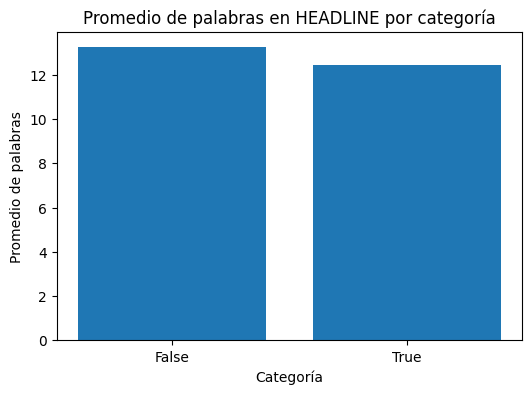

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(
    promedio_headline_category["CATEGORY"].astype(str),
    promedio_headline_category["HEADLINE_NUM_PALABRAS"]
)
plt.title("Promedio de palabras en HEADLINE por categoría")
plt.xlabel("Categoría")
plt.ylabel("Promedio de palabras")
plt.show()

In [ ]:
display(df_headline_validos[[
    "CATEGORY",
    "TOPICS",
    "HEADLINE",
    "HEADLINE_NUM_PALABRAS"
]].head(10))

,CATEGORY,TOPICS,HEADLINE,HEADLINE_NUM_PALABRAS
0,True,Covid-19,Covid-19: mentiras que matan,4
1,False,Política,El Gobierno podrá acceder a las IPs de los móv...,19
2,True,Política,La comunidad musulmana catalana denuncia a Vox...,11
4,True,Sociedad,El censo poblacional 2018 tendrá un costo de $...,10
6,True,Política,Fauci dice que fue sacado de contexto en un nu...,21
7,False,Covid-19,Franja naranja de estado de guerra en chile,8
8,False,Covid-19,Francia decreta el estado de emergencia y el t...,18
9,True,Covid-19,"Con 1.356 vacunas, Norte de Santander inició i...",11
10,True,Sociedad,Despiden al gerente de Mets por acoso sexual a...,10
11,True,Covid-19,Colombia adquirió 40 millones de dosis de vac...,11


## Conclusiones etapa 10

En esta etapa se analizó la variable `HEADLINE` con el objetivo de evaluar su disponibilidad, distribución y posibles diferencias entre noticias falsas y verdaderas.

En primer lugar, se observó que **500 noticias (87.41%) cuentan con titular**, mientras que **72 noticias (12.59%) no presentan esta información**. Esto indica que, en general, la variable tiene una buena cobertura, aunque existe una proporción no despreciable de datos faltantes.

Al analizar la disponibilidad del titular por categoría, se obtiene el siguiente resultado:

| Categoría | Sin headline (%) | Con headline (%) |
| --------- | ---------------: | ---------------: |
| False     |           25.17% |           74.83% |
| True      |            0.00% |          100.00% |

Se observa una diferencia importante: **todas las noticias verdaderas cuentan con titular**, mientras que aproximadamente **un 25% de las noticias falsas no lo tienen**. Este patrón es relevante, ya que sugiere que la ausencia de titular podría estar asociada con contenido falso dentro del dataset.

En cuanto a la longitud de los titulares, se obtuvieron las siguientes estadísticas generales:

* Promedio: **12.80 palabras**
* Mediana: **12 palabras**
* Mínimo: **2 palabras**
* Máximo: **28 palabras**

Esto indica que los titulares son, en general, textos cortos y concisos, como es esperado en contenido periodístico.

Al comparar por categoría, el gráfico muestra que las noticias falsas tienen un promedio de aproximadamente **13.3 palabras**, mientras que las verdaderas presentan alrededor de **12.4 palabras**. Si bien existe una ligera diferencia, esta es **poco significativa**, lo que sugiere que la longitud del titular no es un factor determinante para distinguir entre noticias falsas y verdaderas.

El análisis de la variable `HEADLINE` muestra que la mayoría de las noticias cuentan con titular, lo que la convierte en una fuente potencialmente útil de información. Sin embargo, se identifica un patrón relevante: una proporción considerable de noticias falsas no presenta titular, a diferencia de las verdaderas, que siempre lo incluyen en este dataset.

Por otro lado, la longitud del titular no presenta diferencias significativas entre categorías, lo que indica que esta característica por sí sola no aporta gran capacidad discriminativa. En consecuencia, el uso del `HEADLINE` podría ser útil como complemento del texto principal (`TEXT`), especialmente considerando su disponibilidad, pero no como una variable independiente suficientemente fuerte para la clasificación.


## 11. Análisis de SOURCE

In [ ]:
df_source = df.copy()

In [ ]:
print("Nulos en SOURCE:")
print(df_source["SOURCE"].isnull().sum())

Nulos en SOURCE:
7


In [ ]:
print("Cantidad de fuentes únicas:")
print(df_source["SOURCE"].nunique())

Cantidad de fuentes únicas:
205


In [ ]:
top_sources = (
    df_source["SOURCE"]
    .value_counts(dropna=False)
    .reset_index()
)

top_sources.columns = ["SOURCE", "cantidad"]
top_sources["porcentaje"] = (
    top_sources["cantidad"] / len(df_source) * 100
).round(2)

display(top_sources.head(20))


,SOURCE,cantidad,porcentaje
0,AFPFactual,90,15.73
1,El Universal,29,5.07
2,Milenio,27,4.72
3,El País,20,3.50
4,Mediterráneo Digital,16,2.80
5,El Financiero,15,2.62
6,BBC,15,2.62
7,BBC News,11,1.92
8,Maldita,10,1.75
9,Agencia EFE,10,1.75


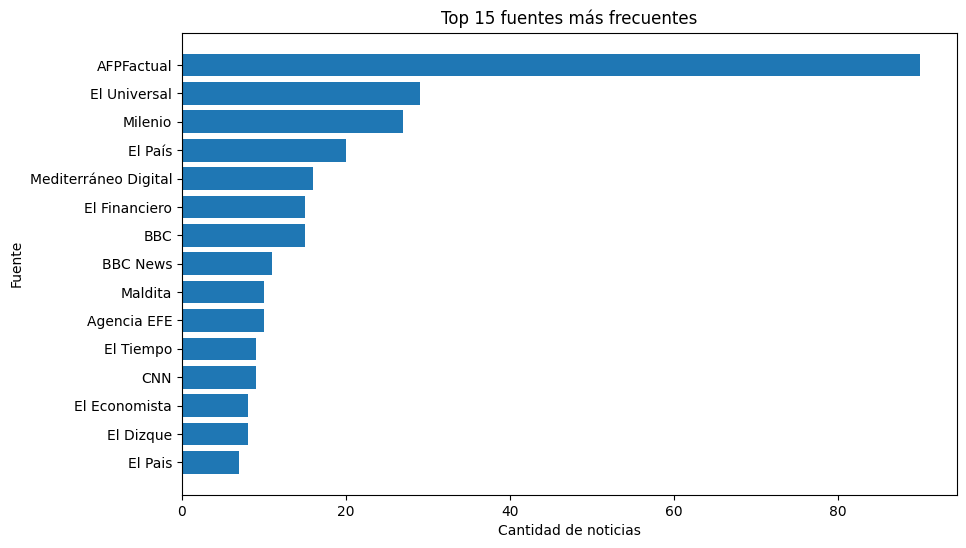

In [ ]:
top_15_sources = top_sources.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_15_sources["SOURCE"].astype(str),
    top_15_sources["cantidad"]
)
plt.title("Top 15 fuentes más frecuentes")
plt.xlabel("Cantidad de noticias")
plt.ylabel("Fuente")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
source_category = pd.crosstab(
    df_source["SOURCE"],
    df_source["CATEGORY"]
)

display(source_category.head(20))

CATEGORY,False,True
SOURCE,,
12 minutos,2,0
2020 News,1,0
AARP,0,1
ABC,1,2
AEMPS,0,1
AFPFactual,90,0
AS,0,1
Actualidad,0,1
Agencia EFE,9,1


In [ ]:
source_category_pct = pd.crosstab(
    df_source["SOURCE"],
    df_source["CATEGORY"],
    normalize="index"
).round(4) * 100

display(source_category_pct.head(20))

CATEGORY,False,True
SOURCE,,
12 minutos,100.00,0.00
2020 News,100.00,0.00
AARP,0.00,100.00
ABC,33.33,66.67
AEMPS,0.00,100.00
AFPFactual,100.00,0.00
AS,0.00,100.00
Actualidad,0.00,100.00
Agencia EFE,90.00,10.00


In [ ]:
source_category_total = pd.crosstab(
    df_source["SOURCE"],
    df_source["CATEGORY"]
)

source_category_total["Total"] = source_category_total.sum(axis=1)

source_category_total = source_category_total.sort_values(
    "Total",
    ascending=False
)

display(source_category_total.head(20))

CATEGORY,False,True,Total
SOURCE,,,
AFPFactual,90,0,90
El Universal,1,28,29
Milenio,2,25,27
El País,0,20,20
Mediterráneo Digital,16,0,16
El Financiero,0,15,15
BBC,2,13,15
BBC News,0,11,11
Agencia EFE,9,1,10


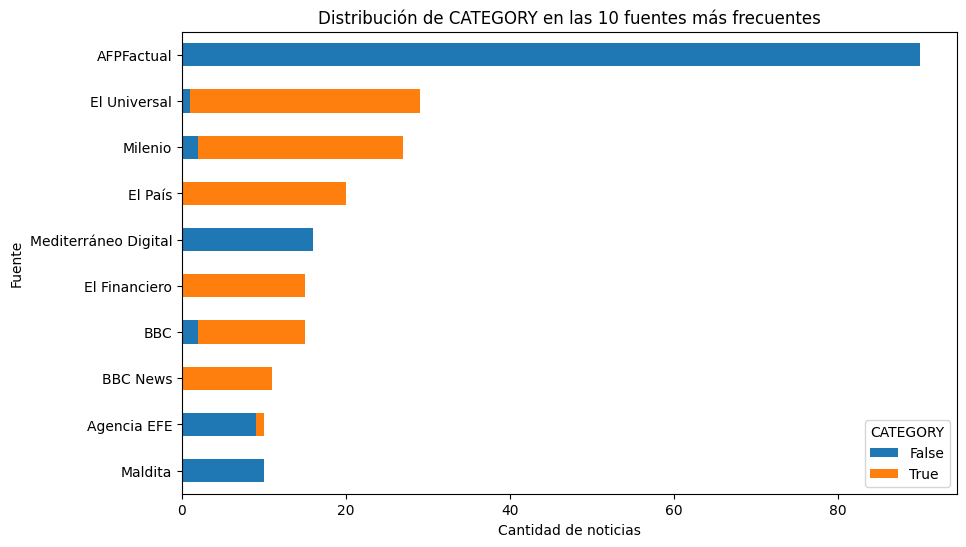

In [ ]:
source_plot = source_category_total.copy()
source_plot.columns = source_plot.columns.astype(str)

top_10_source_names = source_plot.head(10).index

source_plot.loc[top_10_source_names, ["False", "True"]].plot(
    kind="barh",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Distribución de CATEGORY en las 10 fuentes más frecuentes")
plt.xlabel("Cantidad de noticias")
plt.ylabel("Fuente")
plt.gca().invert_yaxis()
plt.legend(title="CATEGORY")
plt.show()

## Conclusion etapa 11

En esta etapa se analizó la variable `SOURCE`, la cual representa la fuente o medio asociado a cada noticia. Aunque esta variable no necesariamente será utilizada en el modelo final, resulta importante revisarla durante el EDA porque puede revelar posibles sesgos en la construcción del dataset.

Las fuentes más frecuentes del corpus son **AFPFactual**, con **90 registros** (**15.73%**), seguida de **El Universal** con **29 registros** (**5.07%**), **Milenio** con **27 registros** (**4.72%**) y **El País** con **20 registros** (**3.50%**). Esto muestra que el dataset no está distribuido uniformemente entre fuentes, sino que algunas tienen mayor presencia que otras.

| Fuente               | Cantidad | Porcentaje |
| -------------------- | -------: | ---------: |
| AFPFactual           |       90 |     15.73% |
| El Universal         |       29 |      5.07% |
| Milenio              |       27 |      4.72% |
| El País              |       20 |      3.50% |
| Mediterráneo Digital |       16 |      2.80% |
| El Financiero        |       15 |      2.62% |
| BBC                  |       15 |      2.62% |
| BBC News             |       11 |      1.92% |
| Maldita              |       10 |      1.75% |
| Agencia EFE          |       10 |      1.75% |

Al cruzar `SOURCE` con `CATEGORY`, se observa un patrón relevante: algunas fuentes aparecen asociadas casi exclusivamente a una sola clase. Por ejemplo, **AFPFactual** tiene **90 noticias clasificadas como False** y ninguna como True. De forma similar, **Maldita**, **Mediterráneo Digital**, **El Dizque** y **Facebook** aparecen únicamente con noticias falsas dentro de los registros mostrados.

En contraste, fuentes como **El País**, **El Financiero**, **BBC News**, **CNN**, **El Tiempo**, **El Economista**, **El Pais** y **Excelsior** aparecen únicamente o casi únicamente asociadas a noticias verdaderas. Por ejemplo, **El País** tiene **20 noticias True** y ninguna False, mientras que **BBC News** presenta **11 noticias True** y ninguna False.

Este comportamiento indica que la variable `SOURCE` podría introducir una posible **fuga de información** si se utiliza directamente como variable predictora. Es decir, el modelo podría aprender a clasificar una noticia como falsa o verdadera basándose en la fuente, en lugar de aprender patrones lingüísticos del contenido textual. Esto afectaría la capacidad de generalización del modelo frente a noticias provenientes de fuentes nuevas o no vistas.

El análisis de `SOURCE` evidencia que algunas fuentes se encuentran fuertemente asociadas a una sola categoría de noticia. Este hallazgo es importante porque sugiere que la variable puede contener información demasiado directa sobre la clase objetivo, generando riesgo de sesgo o fuga de información durante el modelado.

Por ello, aunque `SOURCE` es útil para comprender la composición del dataset, no se recomienda utilizarla como variable principal de entrada en el modelo de clasificación. El modelo debería enfocarse principalmente en el contenido textual de las noticias, especialmente en las variables `TEXT` y, de manera complementaria, `HEADLINE`, para evitar que la predicción dependa artificialmente del medio de origen.
